<a href="https://colab.research.google.com/github/haniyturana/DatabaseManagement/blob/main/Pyspark_IrisClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
spark.stop()

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import os
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes) b
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)




{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [4]:
combineXy = pd.concat([X, y], axis = 1)

# type of flower in iris data
print("List of flowers:")
for i, flower in enumerate(y['class'].unique()):
  print(f"Class{i}: {flower}")

List of flowers:
Class0: Iris-setosa
Class1: Iris-versicolor
Class2: Iris-virginica


In [5]:
spark = SparkSession.builder \
    .appName("IrisDataAnalysis") \
    .getOrCreate()

spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

# convert iris dataset to spark df
iris_spark_df = spark.createDataFrame(combineXy)

iris_spark_df.show()


+------------+-----------+------------+-----------+-----------+
|sepal length|sepal width|petal length|petal width|      class|
+------------+-----------+------------+-----------+-----------+
|         5.1|        3.5|         1.4|        0.2|Iris-setosa|
|         4.9|        3.0|         1.4|        0.2|Iris-setosa|
|         4.7|        3.2|         1.3|        0.2|Iris-setosa|
|         4.6|        3.1|         1.5|        0.2|Iris-setosa|
|         5.0|        3.6|         1.4|        0.2|Iris-setosa|
|         5.4|        3.9|         1.7|        0.4|Iris-setosa|
|         4.6|        3.4|         1.4|        0.3|Iris-setosa|
|         5.0|        3.4|         1.5|        0.2|Iris-setosa|
|         4.4|        2.9|         1.4|        0.2|Iris-setosa|
|         4.9|        3.1|         1.5|        0.1|Iris-setosa|
|         5.4|        3.7|         1.5|        0.2|Iris-setosa|
|         4.8|        3.4|         1.6|        0.2|Iris-setosa|
|         4.8|        3.0|         1.4| 

In [6]:
# EDA

# 1. Print Data Scheme
iris_spark_df.printSchema()

root
 |-- sepal length: double (nullable = true)
 |-- sepal width: double (nullable = true)
 |-- petal length: double (nullable = true)
 |-- petal width: double (nullable = true)
 |-- class: string (nullable = true)



In [7]:
# 2. Check overall details on the statistics
from pyspark.sql.functions import avg, round
cols_features = ["sepal length", "sepal width", "petal length", "petal width"]

print(f"Summary Statistics:\n")
summarystats = iris_spark_df.describe()
for c in cols_features:
  summarystats = summarystats.withColumn(c, round(summarystats[c].cast("float"), 2))

summarystats.show()

print(f"# of data for each class:\n")
iris_spark_df.groupBy("Class").count().show()

print(f"Avg measures each features class:\n")
iris_spark_df.groupBy("class").agg(*[round(avg(c), 2).alias(c) for c in cols_features]).show()

Summary Statistics:

+-------+------------+-----------+------------+-----------+--------------+
|summary|sepal length|sepal width|petal length|petal width|         class|
+-------+------------+-----------+------------+-----------+--------------+
|  count|       150.0|      150.0|       150.0|      150.0|           150|
|   mean|        5.84|       3.05|        3.76|        1.2|          NULL|
| stddev|        0.83|       0.43|        1.76|       0.76|          NULL|
|    min|         4.3|        2.0|         1.0|        0.1|   Iris-setosa|
|    max|         7.9|        4.4|         6.9|        2.5|Iris-virginica|
+-------+------------+-----------+------------+-----------+--------------+

# of data for each class:

+---------------+-----+
|          Class|count|
+---------------+-----+
|    Iris-setosa|   50|
|Iris-versicolor|   50|
| Iris-virginica|   50|
+---------------+-----+

Avg measures each features class:

+---------------+------------+-----------+------------+-----------+
|   

In [8]:
# 3. Check missing value
from pyspark.sql.functions import isnan, when, count, col
iris_spark_df.select([count(when(col(c).isNull(), c)).alias(c) for c in iris_spark_df.columns]).show()


+------------+-----------+------------+-----------+-----+
|sepal length|sepal width|petal length|petal width|class|
+------------+-----------+------------+-----------+-----+
|           0|          0|           0|          0|    0|
+------------+-----------+------------+-----------+-----+



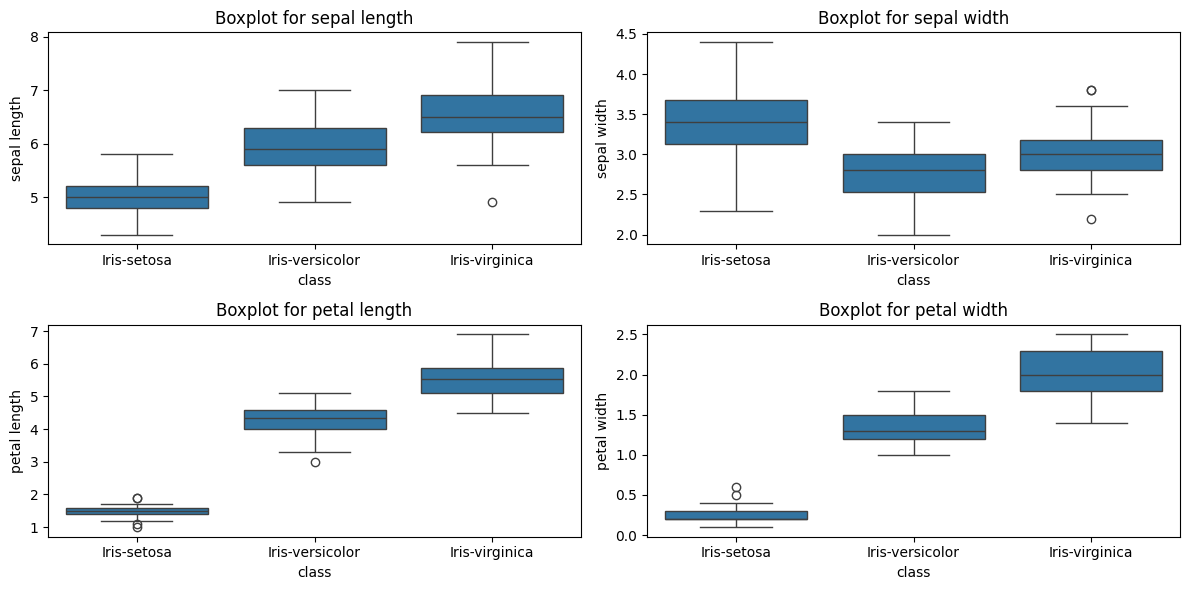

In [9]:
# 4. Check outlier

import matplotlib.pyplot as plt
import seaborn as sns

df = iris_spark_df.toPandas()

plt.figure(figsize= (12,6))

for i, col in enumerate(cols_features):
  plt.subplot(2, 2, i+1)
  sns.boxplot(x = df["class"], y = df[col])

  plt.xlabel("class")
  plt.ylabel(col)
  plt.title(f"Boxplot for {col}")

plt.tight_layout()
plt.show()

1. Remark on the outlier:

*   Outlier existed at :
    - Sepal Length and Width for Iris Virginica
    - Petal Length and Width for Iris Versicolor and Iris Setosa
*   Very less variation seen on Petal Length Iris Setosa because the Q1, Q2, Q2 are scattered around the same range.
*   That's why the plot at looks weird for Iris Setosa.
> Therefore, since the boxplot for Iris Setosa is distributed around same range, the accuracy to detect the Iris Setosa pattern would probably reach 100% because, there is almost no variance in the Iris Setosa data.

2. Strategy:
* Outliers are detected but would be maintained because, we are going to employ Standard Scalar to normalize the data.







In [10]:
# 1. Data Processiong & Feature Engineering

from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler
from pyspark.ml import Pipeline

#          name     role         type demographic  \
#  sepal length   Feature   Continuous        None
#   sepal width   Feature   Continuous        None
#  petal length   Feature   Continuous        None
#   petal width   Feature   Continuous        None
#         class   Target  Categorical

# 1. change target (categorical) to numeric
indexer = StringIndexer(inputCol ="class", outputCol = "label")
# 2. combine features
feature_cols = ['sepal length', 'sepal width', 'petal length', 'petal width']
assembler = VectorAssembler(inputCols = feature_cols, outputCol = "unscaled_features")

# 3. Scaling the features
scaler =  StandardScaler(inputCol = "unscaled_features", outputCol = "features")




In [11]:
# 2. Define Train Test Model

train_data, test_data = iris_spark_df.randomSplit([0.7, 0.3], seed = 42)

print(f"# Train data: \n")
train_data.groupBy("class").count().show()

print(f"Total Train Data: {train_data.count()}\n")

print(f"# Test data: \n")
test_data.groupBy("class").count().show()

print(f"Total Test Data: {test_data.count()}\n")

# Train data: 

+---------------+-----+
|          class|count|
+---------------+-----+
|    Iris-setosa|   25|
|Iris-versicolor|   38|
| Iris-virginica|   31|
+---------------+-----+

Total Train Data: 94

# Test data: 

+---------------+-----+
|          class|count|
+---------------+-----+
|    Iris-setosa|   25|
|Iris-versicolor|   12|
| Iris-virginica|   19|
+---------------+-----+

Total Test Data: 56



## 3. Develop Model:

# **Linear Regression - LR**

In [12]:
6# 3.1. Develop & Train model - LR

from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.mllib.evaluation import MulticlassMetrics
import pyspark.sql.functions as F


# 1. Develop the model (Regression)
lr = LogisticRegression(featuresCol = "features", labelCol = "label")


# 2. Hyperparameter tuning (GridSearch)
paramGrid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.1, 0.01]) \
    .build()

# 3. Cross Validatation
evaluator_lr = MulticlassClassificationEvaluator(labelCol = "label", predictionCol="prediction",
                                              metricName = "accuracy")
cv_lr = CrossValidator(estimator=lr, estimatorParamMaps = paramGrid_lr, evaluator = evaluator_lr,  numFolds = 3)

# 4. Train the model
pipeline_lr =  Pipeline(stages = [indexer, assembler, scaler, cv_lr])
model_lr = pipeline_lr.fit(train_data)


# 5. Evaluate train data
train_predictions = model_lr.transform(train_data)
train_accuracy = evaluator_lr.evaluate(train_predictions)
print(f"Train Accuracy LR: {train_accuracy: .2%}")






Train Accuracy LR:  97.87%


In [13]:
# 3.1.1 Check data on the test dataset - LR

# 1. Evaluate test data
test_predictions = model_lr.transform(test_data)
test_accuracy = evaluator_lr.evaluate(test_predictions)
print(f"Test Accuracy LR: {test_accuracy: .2%}")

# 2. Check accuracy further


prediction_and_labels = test_predictions.select("prediction", "label") \
                        .rdd.map(lambda r: (float(r[0]), float(r[1])))

metrics = MulticlassMetrics(prediction_and_labels)

print(f"Precison: {metrics.weightedPrecision: .2%}")
print(f"Recall: {metrics.weightedRecall: .2%}")
print(f"F1 Score: {metrics.weightedFMeasure():.2%}")


# 3. Check confusion metrix
print("Confusion Matrix:")
print(metrics.confusionMatrix().toArray())



Test Accuracy LR:  96.43%


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Precison:  96.94%
Recall:  96.43%
F1 Score: 96.47%
Confusion Matrix:
[[12.  0.  0.]
 [ 2. 17.  0.]
 [ 0.  0. 25.]]




```
Class0: Iris-setosa
Class1: Iris-versicolor
Class2: Iris-virginica
```

-  Setosa prediction all correct as per what we presume earlier at boxplot output
- Versicolor has 2 wrong prediction classified as Setosa
- Verginica also has all correct classification



In [14]:

# Test Data

12+19+25

#so, match dengan earlier split train test. just to be cautious in case of leakages.



56

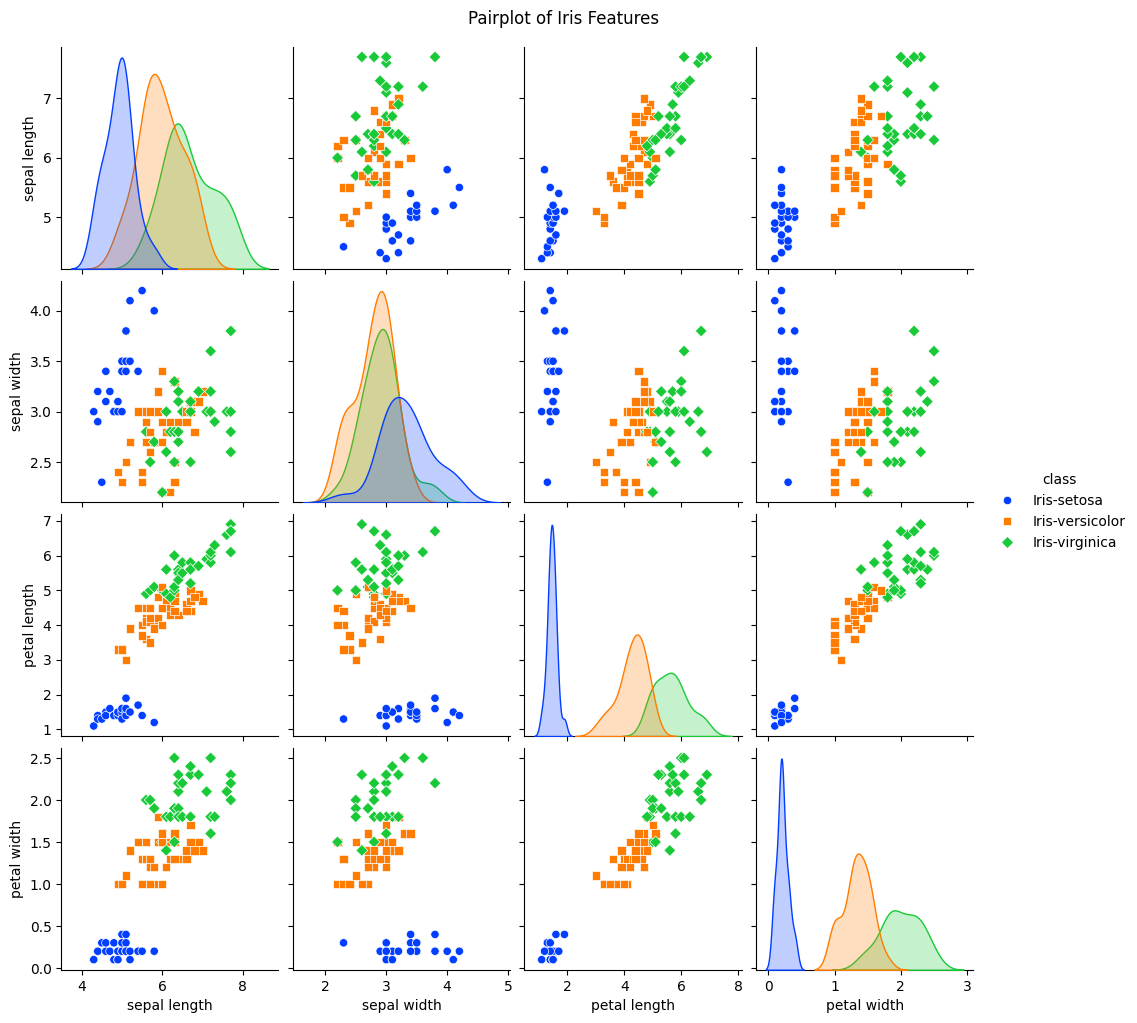

In [15]:
# Plot pair plot

lr_model = train_data.select(feature_cols + ["class"]).toPandas()
plot_lr = sns.pairplot(lr_model, hue = "class", palette = "bright", markers =["o", "s", "D"])
plot_lr.fig.suptitle("Pairplot of Iris Features", y = 1.02)
plt.show()

# Interpret Feature Pairplot Logistic Regression

- Blue : Setosa
- Orange : Versicolor
- Green : Virginica


- Iris Setosa does not overlap with other plot at each features plot. So, prediction of species Setosa is always correct.
- However, Versicolor and Virgina is overlap,
- Distribution at petal width and petal length is less overlap  between versicolor and virginca so this features are the main important to segregate the species.
- Sepal Width is overlap obviously so, it might be less important for this classification model.

In [16]:
# Show the LR model coefficient

best_lrmodel = model_lr.stages[-1].bestModel
coefficients_matrix = best_lrmodel.coefficientMatrix.toArray()
coefficients_df = pd.DataFrame(coefficients_matrix, columns = feature_cols, index = ['Setosa (Coefficient)','Versicolor (Coefficient)', 'Virginica (Coefficient)'])
display(coefficients_df)


,sepal length,sepal width,petal length,petal width
Setosa (Coefficient),0.402576,-0.192628,-0.386729,-0.490379
Versicolor (Coefficient),0.593597,-0.736752,2.129283,2.191867
Virginica (Coefficient),-0.996173,0.929381,-1.742554,-1.701487


# Interpret LR model coefficient

- Petal length and Petal Width for Versicolor has the highest coefficient meaning model uses this features to classify iris species as Versicolor.
- Virginica also has large coefficent especially at petal length and petal width so, the features are important to distinguish Versicolor and Virginica species.
 - Sepal length and Sepal Width are less important due to lower coefficient.
 - Although Setosa has lower coeffiecient but the combination is  of petal length and petal width is important to identiddy the Setosa Coefficient.  

# **Decision Tree - DT**




In [17]:
# 3.2 Develop & Train model - DT

# 1. Develop the model (DT)
dt = DecisionTreeClassifier(featuresCol = "features", labelCol = "label")


# 2. Hyperparameter tuning (GridSearch)
paramGrid_dt = ParamGridBuilder() \
    .addGrid(dt.maxDepth, [3, 5, 10]) \
    .addGrid(dt.maxBins, [32, 64]) \
    .build()

# 3. Cross Validatation
evaluator_dt = MulticlassClassificationEvaluator(labelCol = "label", predictionCol="prediction",
                                              metricName = "accuracy")
cv_dt = CrossValidator(estimator=dt, estimatorParamMaps = paramGrid_dt, evaluator = evaluator_dt,  numFolds = 3)

# 4. Train the model
pipeline_dt =  Pipeline(stages = [indexer, assembler, scaler, cv_dt])
model_dt = pipeline_dt.fit(train_data)


# 5. Evaluate train data
train_predictions_dt = model_dt.transform(train_data)
train_accuracy_dt = evaluator_dt.evaluate(train_predictions_dt)
print(f"Train Accuracy DT: {train_accuracy_dt: .2%}")




Train Accuracy DT:  94.68%


In [18]:
# 3.2.1 Check data on the test dataset - DT

# 1. Evaluate test data
test_predictions =  model_dt.transform(test_data)
test_accuracy = evaluator_dt.evaluate(test_predictions)
print(f"Test Accuracy DT: {test_accuracy: .2%}")

# 2. Check accuracy further
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pyspark.sql.functions as F

prediction_and_labels = test_predictions.select("prediction", "label") \
                        .rdd.map(lambda r: (float(r[0]), float(r[1])))

metrics = MulticlassMetrics(prediction_and_labels)

print(f"Precison: {metrics.weightedPrecision: .2%}")
print(f"Recall: {metrics.weightedRecall: .2%}")
print(f"F1 Score: {metrics.weightedFMeasure():.2%}")


# 3. Check confusion metrix
print("Confusion Matrix:")
print(metrics.confusionMatrix().toArray())





Test Accuracy DT:  96.43%


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Precison:  96.94%
Recall:  96.43%
F1 Score: 96.47%
Confusion Matrix:
[[12.  0.  0.]
 [ 2. 17.  0.]
 [ 0.  0. 25.]]


DT model

```
Class0: Iris-setosa
Class1: Iris-versicolor
Class2: Iris-virginica
```

-  Setosa prediction all correct as per what we presume earlier at boxplot output
- Versicolor has 2 wrong prediction classified as Setosa
- Verginica also has all correct classification

This is same prediction of classification as per LR


In [19]:
#!pip install handyspark

Pyspark Tree Structure:
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_cea6f09590e8, depth=3, numNodes=7, numClasses=3, numFeatures=4
  If (feature 2 <= 1.4392979892196842)
   Predict: 2.0
  Else (feature 2 > 1.4392979892196842)
   If (feature 2 <= 2.849222550087946)
    Predict: 0.0
   Else (feature 2 > 2.849222550087946)
    If (feature 3 <= 2.411297502470143)
     Predict: 0.0
    Else (feature 3 > 2.411297502470143)
     Predict: 1.0

SKlearn DT Plot:


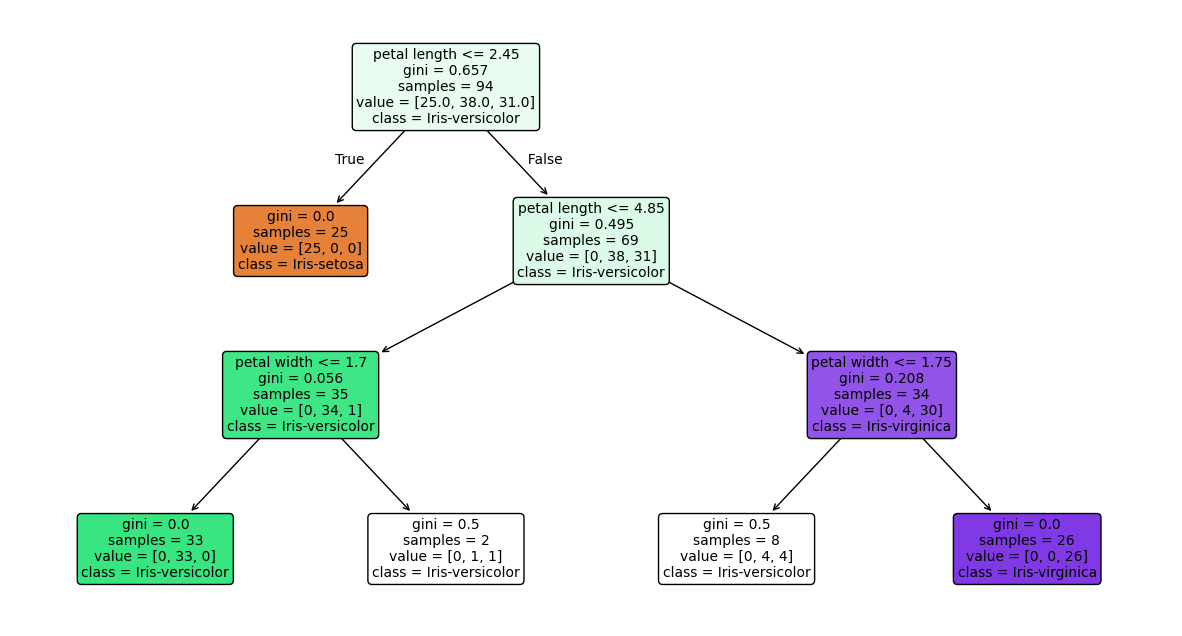

In [20]:
# Plot the Tree
print("Pyspark Tree Structure:")
dt_model = model_dt.stages[-1].bestModel

print(dt_model.toDebugString)

# using pyspark to visualize the tree is quite tedious hence, using Scikit-Learn so, convert data to normal dataframe
from sklearn.tree import DecisionTreeClassifier as SKDecisionTreeClassifier
from sklearn import tree as sk_tree
from sklearn.preprocessing import LabelEncoder


sckit_dt = train_data.toPandas()
X = sckit_dt[feature_cols]
le = LabelEncoder()
y = le.fit_transform(sckit_dt['class'])

plot_dt = SKDecisionTreeClassifier(max_depth = 3, criterion = 'gini', random_state = 42)
plot_dt.fit(X, y)

print("SKlearn DT Plot:")
plt.figure(figsize = (15, 8))
sk_tree.plot_tree(plot_dt, feature_names = feature_cols, class_names = le.classes_, filled = True, rounded = True, fontsize = 10)

plt.savefig('DecisionTreeIris.jpg', format = 'jpg', bbox_inches = 'tight')
plt.show()

# Interpret Decision Tree Graph

Color Code :
- Orange = Setosa
- Green = Versicolor
- Purple = Virginica
- White = no dominant class yet

Solid Color = High Purity

Light Color = Low Purity hence probably contain mix class species

- If petal length <= 2.45cm , it is Iris Setosa (Color Orange -  100% pure)
- Else if petal length >2.45cm check next condition:

  - If petal length <= 4.85cm check:
    - If petal width <=1.7cm, it is Iris Versicolor (Solid Green - 100% pure)
    - Else if petal width > 1.7cm, it is Iris Versicolor but (Color White - Low
  Purity) so mixture of Versicolor and Virginica.

  - Else if petal length >4.85cm:
     -  If petal width <= 1.75cm, it is Iris Virginica but (light purple color-low purity) so has mizture of Versiolor and Virginica. Gini also 0.5
     -  If petal width > 1.75cm, it is Iris Virginica (Dark Purple - High Purity)

In [22]:
# Feature Importance Decision Tree

dt_array = dt_model.featureImportances.toArray()
feature_importance_dt = pd.DataFrame({'Feature': feature_cols, 'Importance': dt_array})
feature_importance_dt = feature_importance_dt.sort_values(by = 'Importance', ascending = False)
display(feature_importance_dt)

,Feature,Importance
2,petal length,0.945205
3,petal width,0.054795
1,sepal width,0.000000
0,sepal length,0.000000


#Interpret the Feature Importance based on the DT models.

From the Feature Importance above, it seems that petal length is the most significant feature at classifying the iris species.

# **Random Forest - RF**

In [23]:
# 3.3. Develop & Train model - RF

# 1. Develop the model (RF)
rf =RandomForestClassifier(featuresCol = "features", labelCol = "label")


# 2. Hyperparameter tuning (GridSearch)
paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf.numTrees, [20, 50, 100]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# 3. Cross Validatation
evaluator_rf = MulticlassClassificationEvaluator(labelCol = "label", predictionCol="prediction",
                                              metricName = "accuracy")
cv_rf = CrossValidator(estimator=rf, estimatorParamMaps = paramGrid_rf, evaluator = evaluator_rf,  numFolds = 3)

# 4. Train the model
pipeline_rf =  Pipeline(stages = [indexer, assembler, scaler, cv_rf])
model_rf = pipeline_rf.fit(train_data)


# 5. Evaluate train data
train_predictions_rf = model_rf.transform(train_data)
train_accuracy_rf = evaluator_rf.evaluate(train_predictions_rf)
print(f"Train Accuracy RF: {train_accuracy_rf: .2%}")

Train Accuracy RF:  100.00%


In [24]:
# 3.3.1 Check data on the test dataset - Random Forest

# 1. Evaluate test data
test_predictions =  model_rf.transform(test_data)
test_accuracy = evaluator_rf.evaluate(test_predictions)
print(f"Test Accuracy RF: {test_accuracy: .2%}")

# 2. Check accuracy further
prediction_and_labels = test_predictions.select("prediction", "label") \
                        .rdd.map(lambda r: (float(r[0]), float(r[1])))

metrics = MulticlassMetrics(prediction_and_labels)

print(f"Precison: {metrics.weightedPrecision: .2%}")
print(f"Recall: {metrics.weightedRecall: .2%}")
print(f"F1 Score: {metrics.weightedFMeasure():.2%}")


# 3. Check confusion metrix
print("Confusion Matrix:")
print(metrics.confusionMatrix().toArray())





Test Accuracy RF:  98.21%


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Precison:  98.35%
Recall:  98.21%
F1 Score: 98.23%
Confusion Matrix:
[[12.  0.  0.]
 [ 1. 18.  0.]
 [ 0.  0. 25.]]


RF model

```
Class0: Iris-setosa
Class1: Iris-versicolor
Class2: Iris-virginica
```

-  Setosa prediction all correct as per what we presume earlier at boxplot output
- Versicolor has 1 wrong prediction classified as Setosa
- Verginica also has all correct classification

Seems it has improved compared to LR and DT earlier, it produced only 1 wrong misclassification

In [27]:
# Feature Importance RF

best_rfmodel = model_rf.stages[-1].bestModel
rf_array = best_rfmodel.featureImportances.toArray()
features_cols = assembler.getInputCols()
featureimportance_rf = pd.DataFrame({"Feature": features_cols, "Importance": rf_array})

featureimportance_rf = featureimportance_rf.sort_values(by = "Importance", ascending = False)

display(featureimportance_rf)

,Feature,Importance
2,petal length,0.451113
3,petal width,0.410962
0,sepal length,0.123179
1,sepal width,0.014746


# Interpret Feature Importance RF

- Petal Length and Petal Width are the most important features at classifying the Iris Species.
- The result is consistent with the behaviour observed in Logistic Regression and Decision Tree.



# 4. Model Comparison


### A. Model Accuracy Test

| Model    | Train Accuracy | Test Accuracy | Precision | Recall |  F1 Score |Strengths | Limitations |
|----------|----------|-----------| ------------|----------|----------|----------|----------|
| Logistic Regression |97.87|96.43|96.43|96.43|96.47|Fast and Easy Interpretation| Assume Linear Relationship between features and log-odds
| Decision Tree        |94.68|96.43|96.94|96.43|96.47|Simple & Robust to Outlier|Unstable(Small change in data can change the tree)|
| Random Forest |97.87|98.21|98.35|98.21|98.23|More Robust & Reduce Overfitting|Complex & Difficult to Visualize

---
### B. Confusion Matrix

Confusion Matrix: LR
[[12.  0.  0.]
 [ 2. 17.  0.]
 [ 0.  0. 25.]]

|| Predicted 0 | Predicted 1 | Predicted 2|
|---:|:---:|:---:|:---:|
| **Actual 0** | **12** | 0 | 0 |
| **Actual 1** | 2 | **17* | 0 |
| **Actual 2** | 0 | 0 | **25** |

 Confusion Matrix: DT
[[12.  0.  0.]
 [ 2. 17.  0.]
 [ 0.  0. 25.]]
|| Predicted 0 | Predicted 1 | Predicted 2|
|---:|:---:|:---:|:---:|
| **Actual 0** | **12** | 0 | 0 |
| **Actual 1** | 2 | **17* | 0 |
| **Actual 2** | 0 | 0 | **25** |

 Confusion Matrix:RF
[[12.  0.  0.]
 [ 1. 18.  0.]
 [ 0.  0. 25.]]

|| Predicted 0 | Predicted 1 | Predicted 2|
|---:|:---:|:---:|:---:|
| **Actual 0** | **12** | 0 | 0 |
| **Actual 1** | 1 | **18* | 0 |
| **Actual 2** | 0 | 0 | **25** |


Interpretation:

* All models produced high accuracy scores at both train and test dataset (above 94%).
* In overall, the best performing models are Random Forest because it has the highest score across all metrices such as accuracy, precision, recall and F1 Score.
* There is a marginal difference between training and testing dataset across all models.
* It indicates that the model are generalized well on the unseen data with no significant sign of over or under-fitting. Despite:
  - Training accuracy is slightly higher than testing accuracy on the Logistic Regression which is quite common occurance in model training.
  - Decision Tress has slightly larger gap between accuracy on training and testing dataset but it remain as a robust model.

* From the confusion matrix, both Logistic Regression and Decision Tree wrongly classified 2 species Iris Versicolor as Iris Setosa.
* On contrary, Random Forest only produced 1 misclassification error by classifying Iris Versicolor as Iris Setosa.
* There is no misclassfication error at classifying type of Setosa and Virginica probably due to distinct features and less noise in the dataset for this species.



List of flowers:
-----------------------
* Class0: Iris-setosa
* Class1: Iris-versicolor
* Class2: Iris-virginica